# Intensive Care Unit Decision-Support Tool

**Group Project for Responsible Data Science**

**Submission Deadline: March 24, 2025**

This notebook provides a comprehensive analysis of ICU patient data to predict mortality, including advanced visualization, model explanations, and fairness evaluations.

## 1. Setup and Configuration

In [1]:
# Import standard libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import custom modules
import data_processing as dp
import visualization as viz
import modeling as mdl
import utils
import config

# Set visualization style
viz.set_visualization_style()
plt.style.use('seaborn-v0_8-whitegrid')

# Create directories if they don't exist
os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.MODELS_DIR, exist_ok=True)

## 2. Data Loading and Preprocessing

Number of samples	: 91713
Number of features	: 186


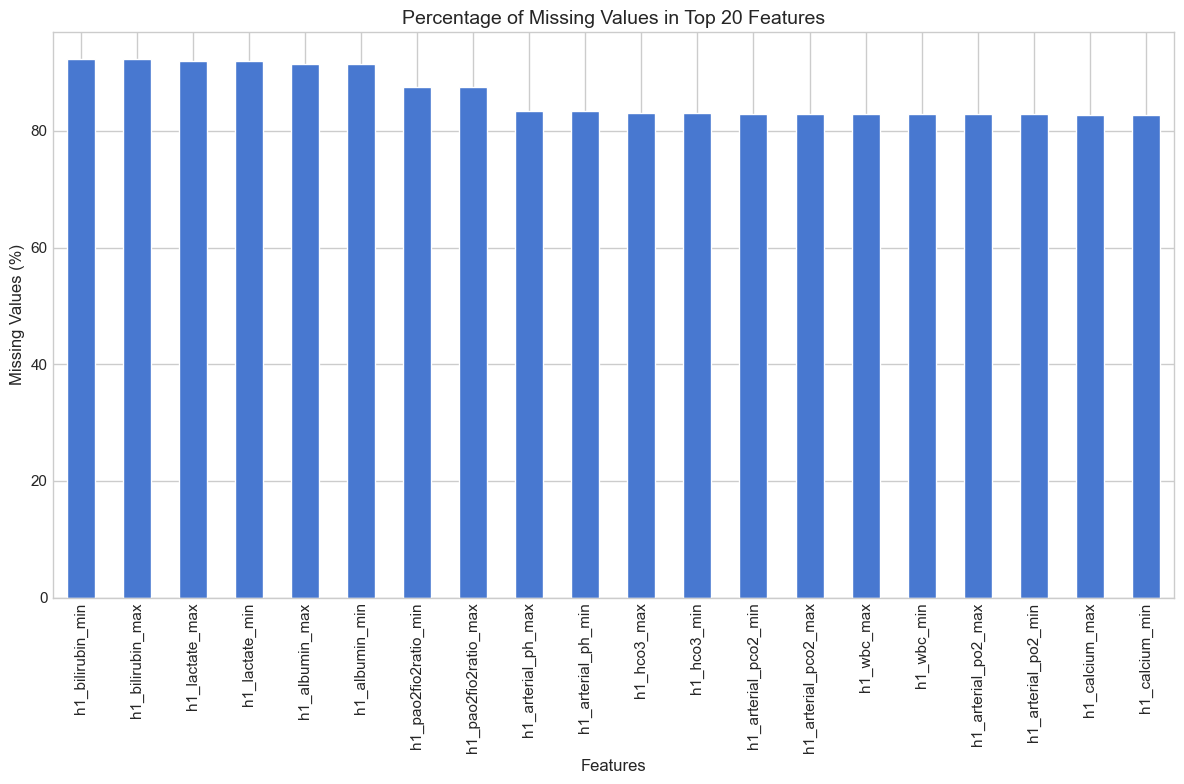

Training set size: (73370, 185)
Testing set size: (18343, 185)
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%
Number of columns with >80% missing values: 34
Number of numerical features: 143
Number of categorical features: 8
Processed data saved to results/processed_data.pkl

Basic statistics:
Number of training samples: 73370
Number of testing samples: 18343
Number of numerical features: 143
Number of categorical features: 8
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%


In [2]:
# Load data and data dictionary
df, description_dict = dp.load_data(config.DATA_DIR)
utils.print_dataset_info(df)

# Analyze missing values
missing_percentages, high_missing_cols = dp.analyze_missing_values(df)

# Plot missing values
viz.plot_missing_values(missing_percentages)

# Split data for modeling
X, y = dp.split_features_target(df, config.TARGET_COLUMN)
X_train, X_test, y_train, y_test = dp.create_train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

# Filter high missing columns and identify column types
X_train_filtered, X_test_filtered, high_missing_cols = dp.filter_high_missing_columns(
    X_train, X_test, threshold=config.MISSING_THRESHOLD_HIGH
)
numerical_cols, categorical_cols = dp.identify_column_types(X_train_filtered)

# Save processed data for later use
dp.save_processed_data(
    X_train_filtered, X_test_filtered, y_train, y_test,
    numerical_cols, categorical_cols, description_dict,
    os.path.join(config.RESULTS_DIR, 'processed_data.pkl')
)

## 3. Enhanced Data Exploration

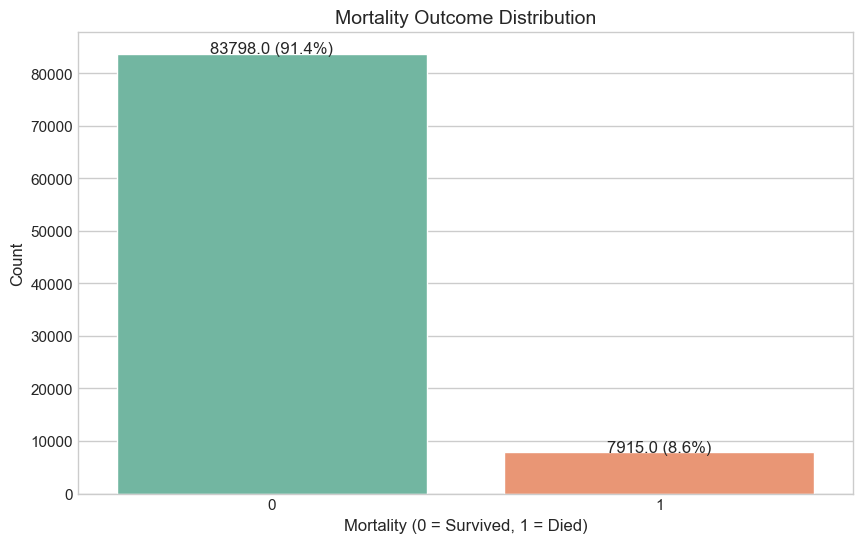

Dead: 7915 (8.63%) Survived: 83798 (91.37%) out of a total of 91713


In [3]:
# Visualize target variable distribution
viz.plot_target_distribution(df)

c:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


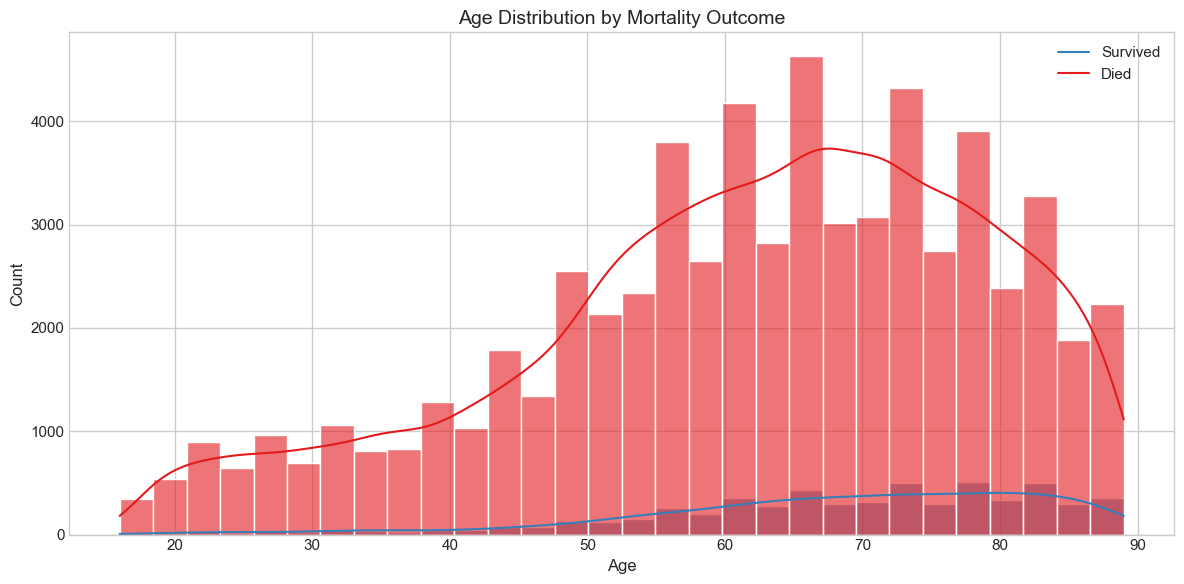

In [4]:
# Explore age distribution by mortality outcome
viz.plot_age_distribution_by_mortality(X_train_filtered, y_train)

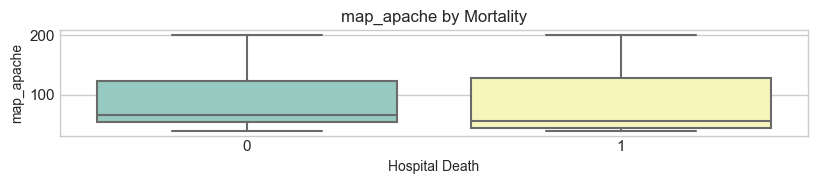

In [5]:
# Analyze key physiological parameters by mortality
physiological_vars = ['heart_rate', 'map_apache', 'resp_rate', 'temperature', 'wbc', 'creatinine']
viz.plot_physiological_vars_by_mortality(X_train_filtered, y_train, physiological_vars)

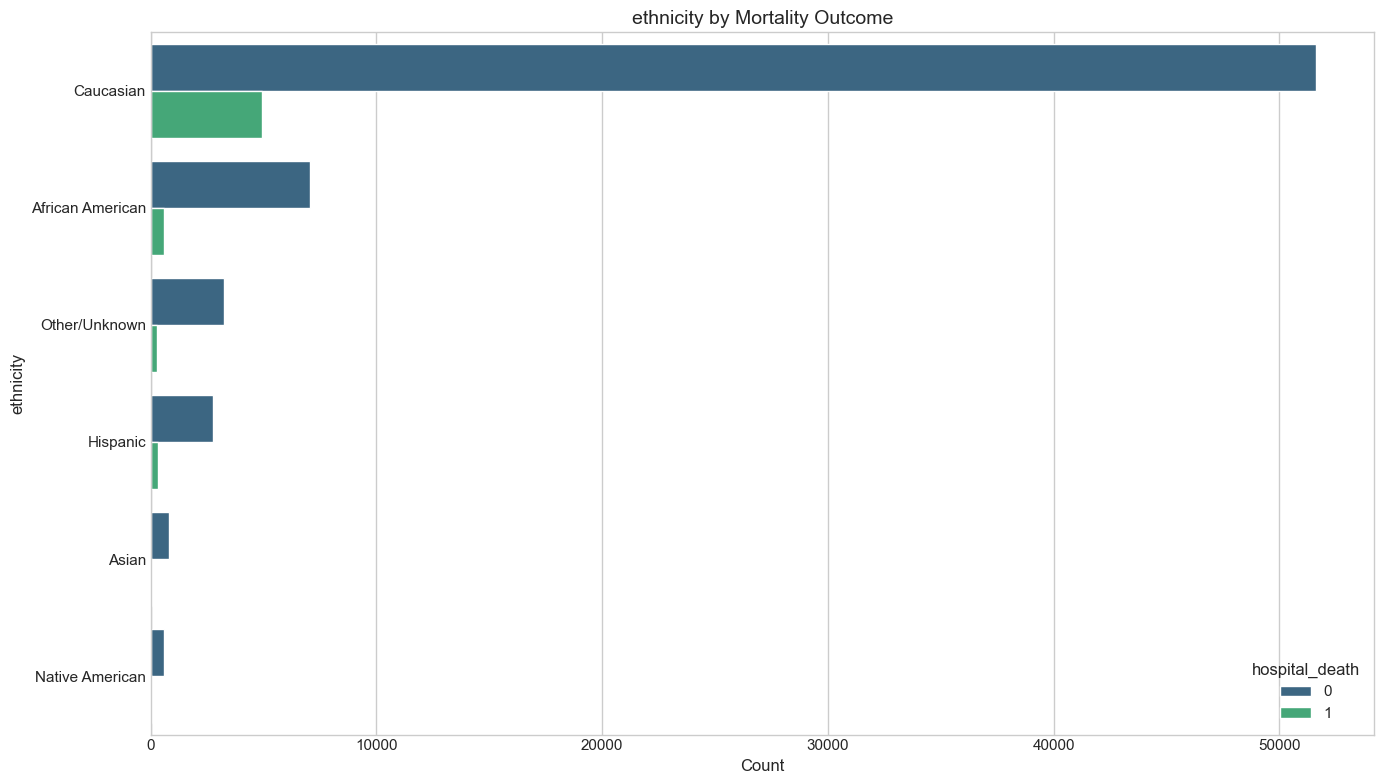

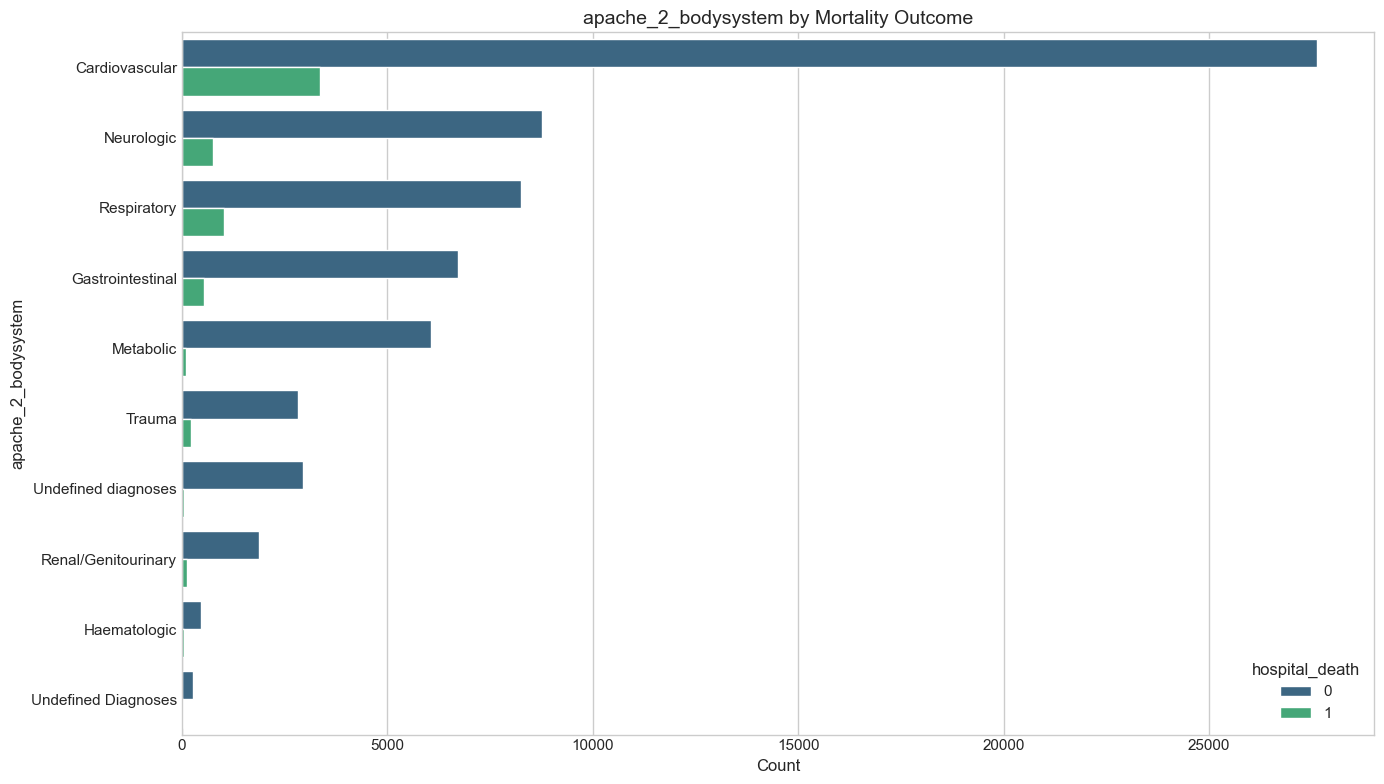

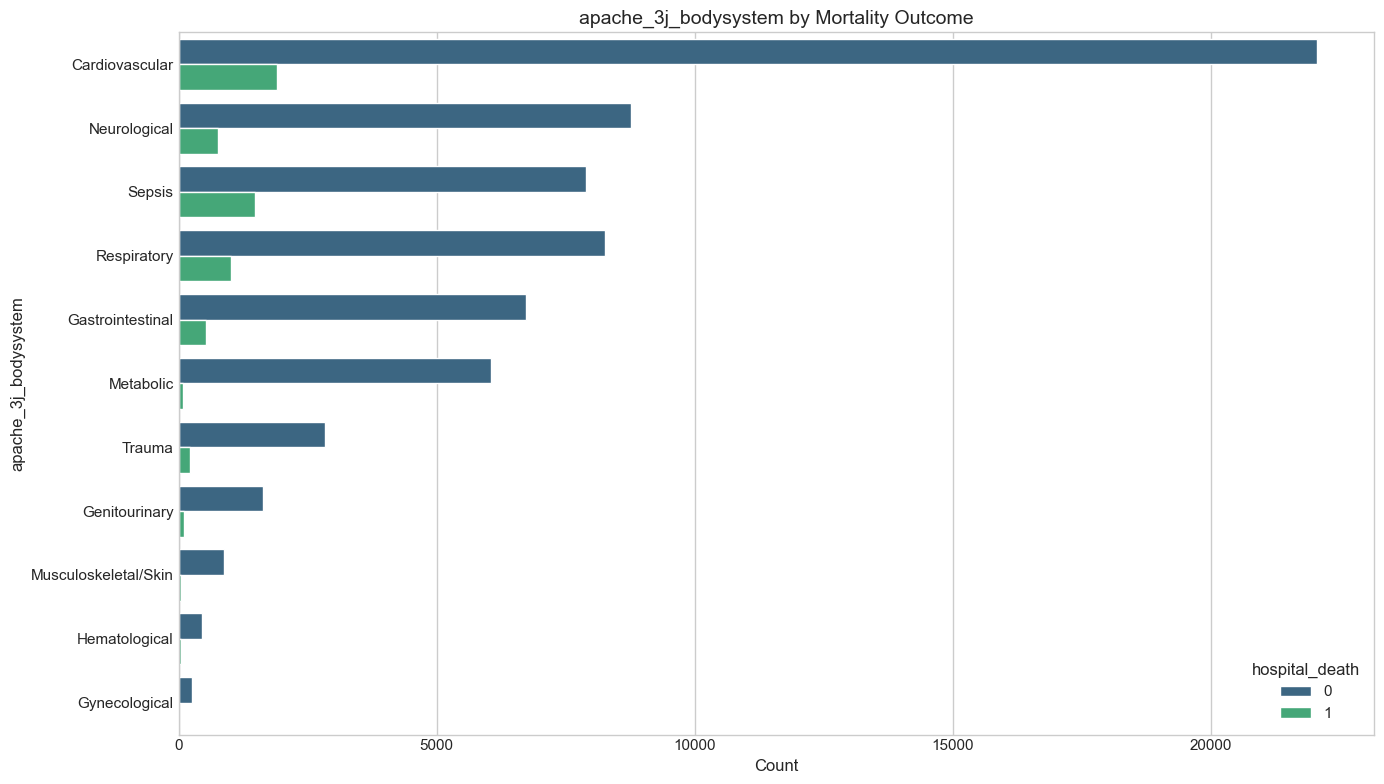

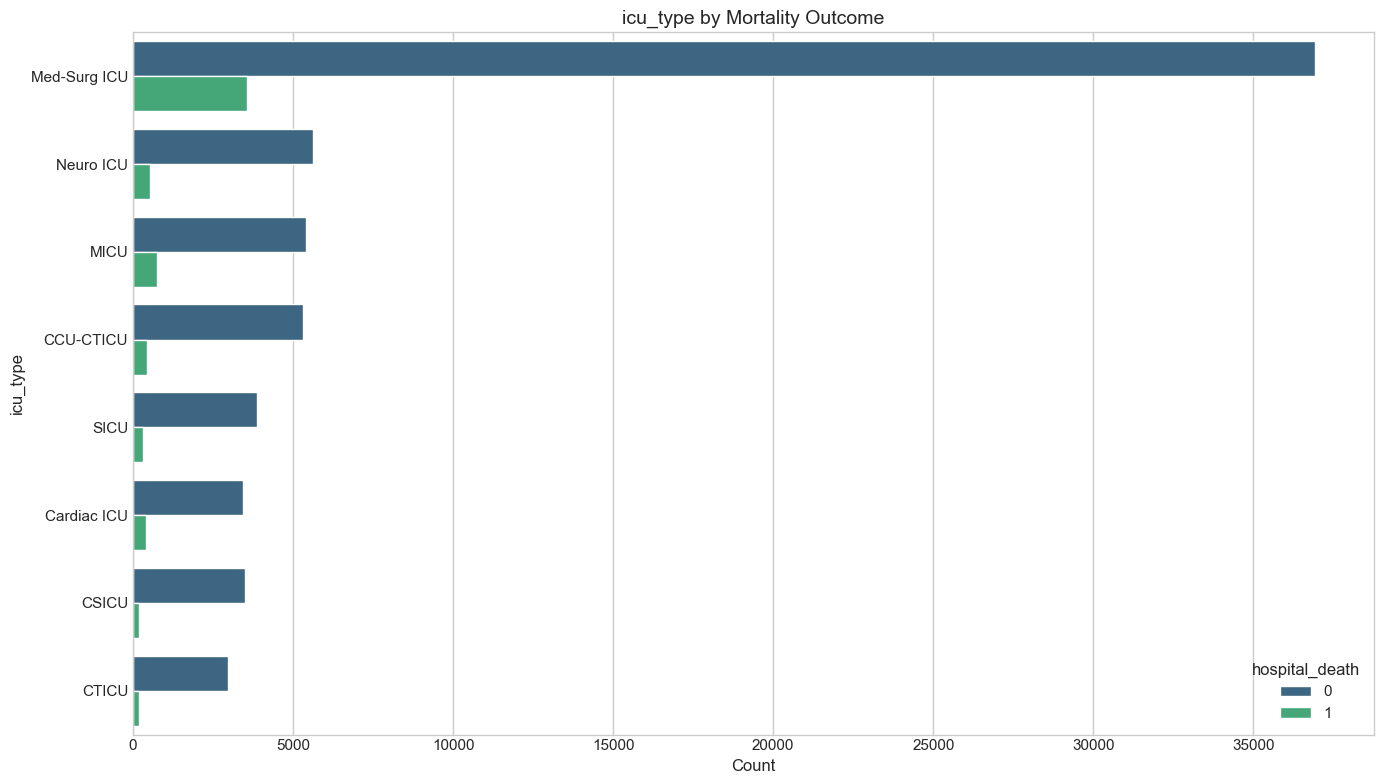

In [6]:
# Visualize categorical features
key_categorical = ['ethnicity', 'apache_2_bodysystem', 'apache_3j_bodysystem', 'icu_type']
viz.plot_categorical_features_by_mortality(X_train_filtered, y_train, key_categorical)

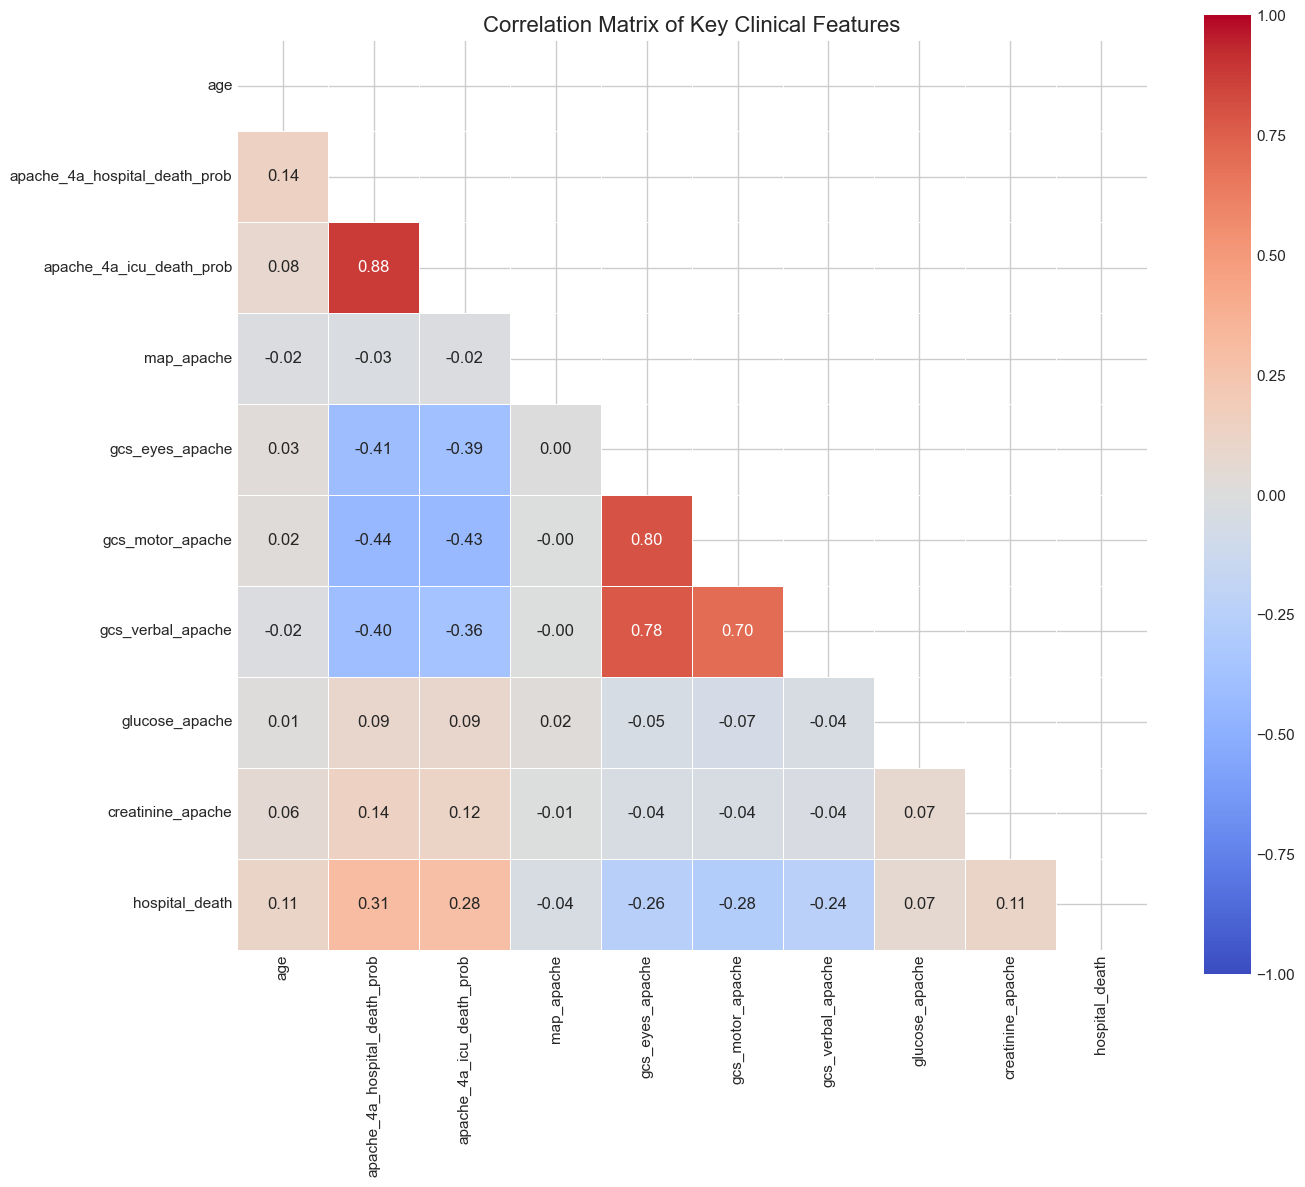

In [7]:
# Correlation analysis
viz.plot_correlation_matrix_of_clinical_features(X_train_filtered, y_train)

## 4. Model Training and Evaluation

In [8]:
# Train models with different imputation strategies
pipelines, scores = mdl.train_and_evaluate_all_imputation_strategies(
    X_train_filtered, X_test_filtered, y_train, y_test,
    numerical_cols, categorical_cols, config.IMPUTATION_STRATEGIES, config.RF_PARAMS
)


Training model with simple imputation...
Evaluation Results - Simple Imputation:
ROC AUC: 0.887
Accuracy: 0.860
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     16760
           1       0.35      0.70      0.46      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.79      0.69     18343
weighted avg       0.92      0.86      0.88     18343


Training model with median imputation...
Evaluation Results - Median Imputation:
ROC AUC: 0.887
Accuracy: 0.862
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16760
           1       0.35      0.70      0.47      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.79      0.69     18343
weighted avg       0.92      0.86      0.88     18343



18343

Confusion Matrix Raw Values for simple:
[[14663  2097]
 [  470  1113]]


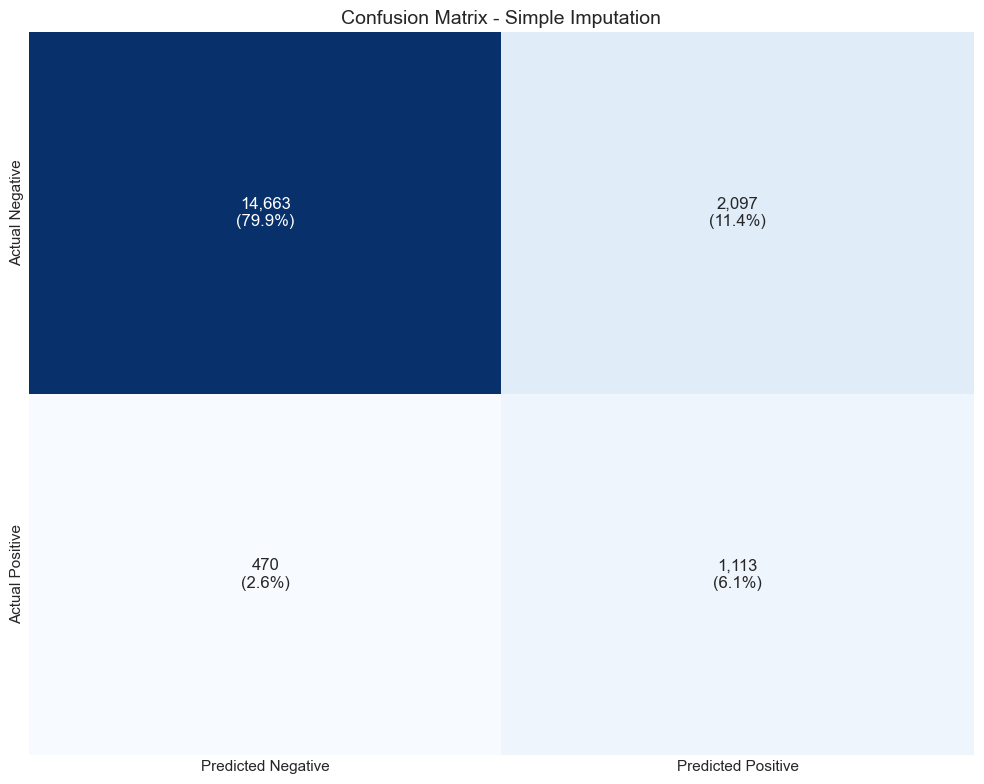

18343

Confusion Matrix Raw Values for median:
[[14708  2052]
 [  472  1111]]


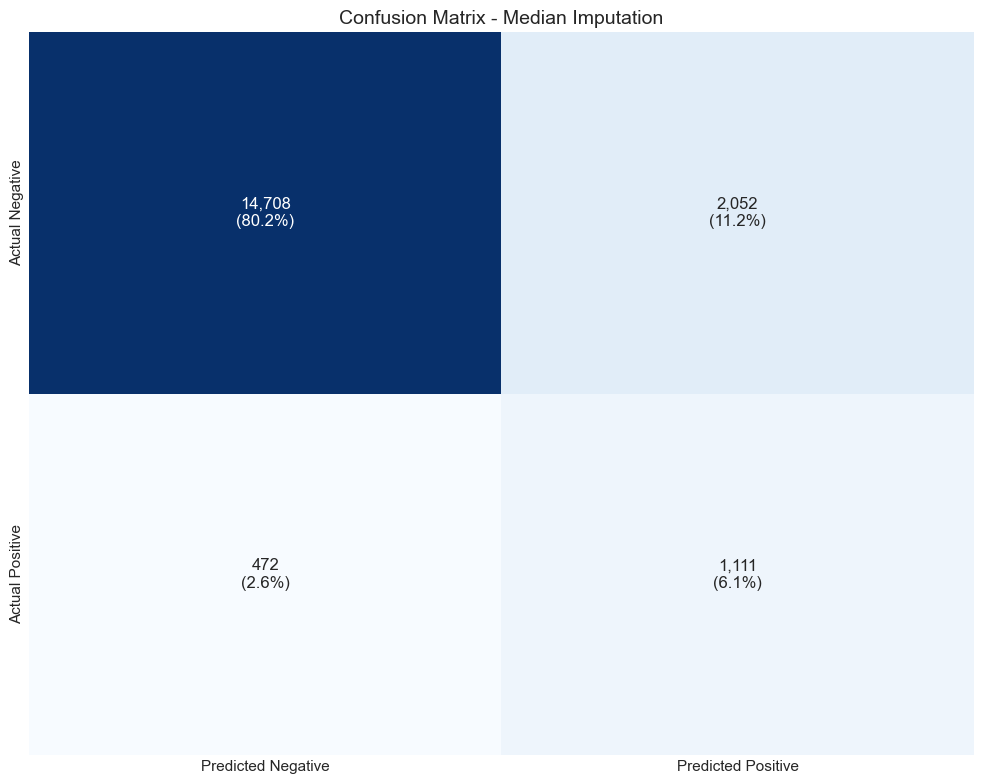

In [9]:
# Create enhanced confusion matrices for all models
for strategy, pipeline in pipelines.items():
    print(len(X_test_filtered))

    y_pred = pipeline.predict(X_test_filtered)
    viz.plot_enhanced_confusion_matrix(y_test, y_pred, strategy)

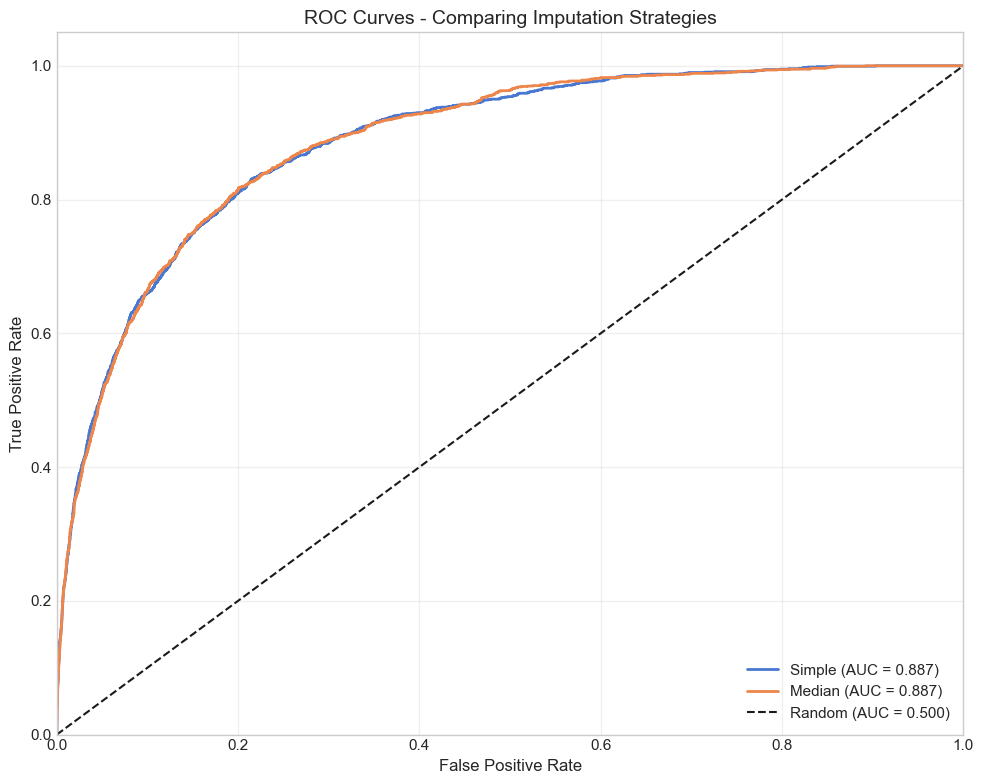

In [10]:
# Compare ROC curves for different imputation strategies
viz.plot_roc_curves_comparison(
    y_test, {strategy: pipeline.predict_proba(X_test_filtered)[:, 1] for strategy, pipeline in pipelines.items()}
)

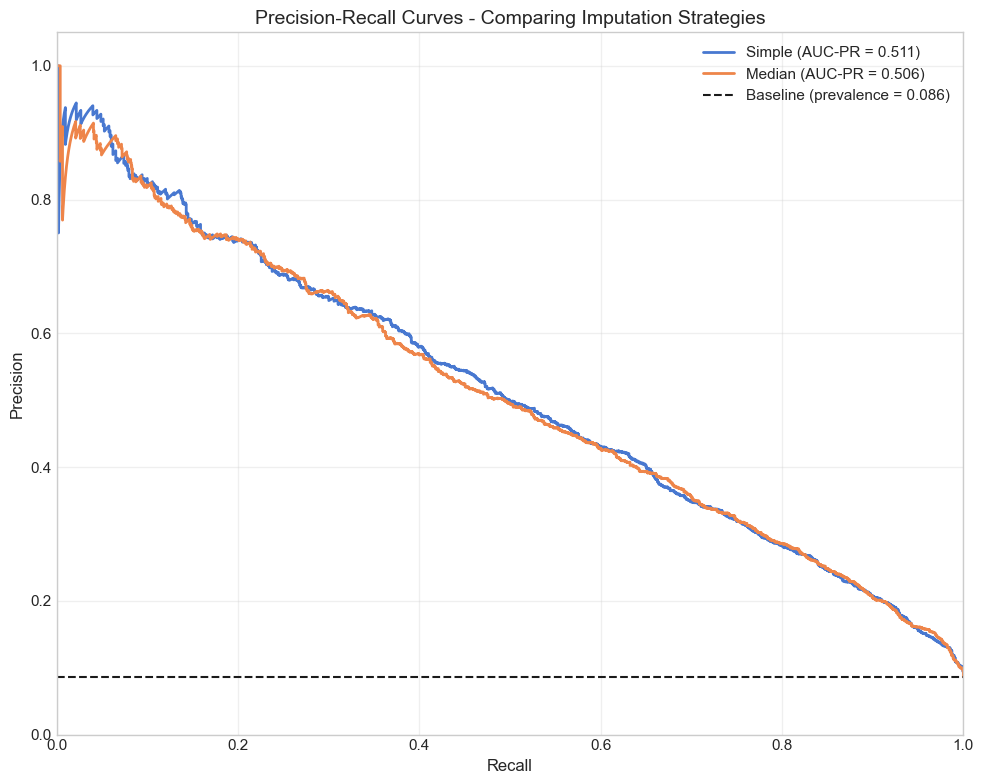

In [11]:
# Compare Precision-Recall curves for different imputation strategies
viz.plot_precision_recall_curves_comparison(
    y_test, {strategy: pipeline.predict_proba(X_test_filtered)[:, 1] for strategy, pipeline in pipelines.items()}
)

In [12]:
# Find the best imputation strategy
comparison_df, best_strategy = utils.compare_models({s: scores[s] for s in config.IMPUTATION_STRATEGIES}, 'roc_auc')

print(f"Best imputation strategy: {best_strategy}")
print(comparison_df)

# Save the best model for later use
best_model = pipelines[best_strategy]
with open(os.path.join(config.MODELS_DIR, f'best_model_{best_strategy}.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

Best imputation strategy: median
         roc_auc
median  0.887291
simple  0.886912


## 5. Feature Importance Analysis

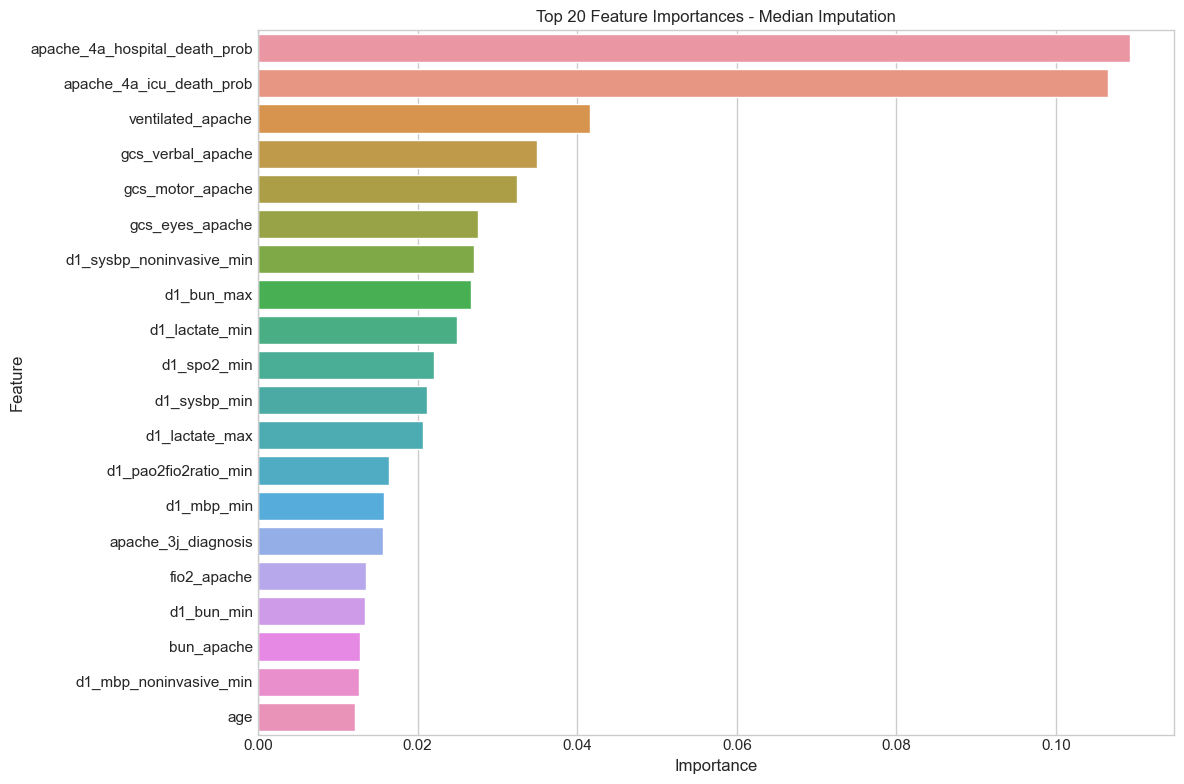

Top 20 most important features:


,Feature,Importance
133,apache_4a_hospital_death_prob,0.109317
134,apache_4a_icu_death_prob,0.106459
37,ventilated_apache,0.041542
23,gcs_verbal_apache,0.035012
21,gcs_motor_apache,0.032494
20,gcs_eyes_apache,0.027534
62,d1_sysbp_noninvasive_min,0.027098
89,d1_bun_max,0.026727
106,d1_lactate_min,0.024884
56,d1_spo2_min,0.022095


In [13]:
# Extract feature names and importances
feature_names = mdl.get_feature_names(pipelines[best_strategy].named_steps['preprocessor'])
feature_importances = pipelines[best_strategy].named_steps['classifier'].feature_importances_

# Plot top 20 features
importance_df = viz.plot_feature_importance(
    feature_names, feature_importances, top_n=20,
    title=f'Top 20 Feature Importances - {best_strategy.capitalize()} Imputation'
)

# Display feature importance table
print("Top 20 most important features:")
display(importance_df.head(20))

In [ ]:
# Try to add SHAP analysis if it's available
mdl.analyze_with_shap(best_model, X_test_filtered, feature_names)

## 6. Model Comparison with APACHE IV

In [ ]:
# Compare with APACHE IV prediction if available
apache_result = mdl.compare_with_apache_iv(X_test_filtered, y_test, best_model.predict_proba(X_test_filtered)[:, 1])

if apache_result is not None:
    apache_auc, our_auc = apache_result
    viz.plot_model_vs_apache_comparison(X_test_filtered, y_test, best_model, best_strategy, apache_auc, our_auc)

## 7. Fairness Analysis

In [ ]:
# Analyze model performance across different ethnic groups
best_model = pipelines[best_strategy]
y_pred = best_model.predict(X_test_filtered)
y_proba = best_model.predict_proba(X_test_filtered)[:, 1]

fairness_df, metrics_by_ethnicity = mdl.analyze_fairness_by_ethnicity(
    X_test_filtered, y_test, y_pred, y_proba
)

if fairness_df is not None:
    print("Fairness Metrics by Ethnicity:")
    display(fairness_df)
    
    # Plot fairness metrics
    viz.plot_fairness_metrics(fairness_df, metrics_by_ethnicity)

## 8. Analysis by Body System

In [ ]:
# Get a high-level overview of body system performance
body_system_df, body_system_metrics = mdl.analyze_performance_by_body_system(
    X_test_filtered, y_test, best_model
)

if body_system_df is not None:
    print("Model Performance by Body System:")
    display(body_system_df)
    
    # Plot performance by body system
    viz.plot_performance_by_body_system(body_system_df, body_system_metrics)

## 9. Additional Analysis: In-Depth Body System Modeling

In [ ]:
# Perform a more detailed analysis by body system
body_system_results = mdl.analyze_by_body_system(
    X_train_filtered, y_train, 
    X_test_filtered, y_test, 
    numerical_cols, categorical_cols, 
    best_strategy
)

if body_system_results is not None and len(body_system_results) > 0:
    viz.plot_body_system_analysis_results(body_system_results, body_system_df, feature_names)

## 10. Finding Optimal Classification Threshold

In [ ]:
# Find the optimal classification threshold for our best model
thresholds_analysis = mdl.analyze_classification_thresholds(best_model, X_test_filtered, y_test)
viz.plot_threshold_analysis_results(thresholds_analysis)